In [1]:
import numpy as np
from scipy.special import gamma, zeta, eval_hermite, factorial
import matplotlib.pyplot as plt

In [2]:
def sech(x):
    return 1 / np.cosh(x)

def hermite(x, n, kappa):
    x_scaled = np.sqrt(kappa) * x
    norm = np.sqrt(np.sqrt(kappa / np.pi)) / np.sqrt(2**n * factorial(n))
    psi = norm * eval_hermite(n, x_scaled) * np.exp(-x_scaled**2 / 2)
    return psi


In [3]:
_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

In [4]:
from mpmath import *
def gamma_t(time, const, plot=0, form=0):
    center = (time[0] + time[-1]) / 2
    def Li_2(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(2, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_3(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(3, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_4(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(4, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_5(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(5, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_6(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(6, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    if form==0:
        top = (const/2)/(np.cosh(const*(time-center)))**2
        bottom = 1-(1/2)*(np.tanh(const*(time-center))-np.tanh(const*(time[0]-center)))
    elif form==1:                                                      
        top = (6*const**3/np.pi**2)*(time-center)**2/(np.cosh(const*(time-center)))**2
        def f(t):
            return 6 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) / np.pi**2
        bottom = 1-(f(const*(time-center))-f(const*(time[0]-center)))
    elif form==2:                                                    
        top = (45*const**5/2/np.pi**4) * ((time-center)**2 - (np.pi/const)**2/12)**2/ (np.cosh(const * (time - center)))**2
        def f(t):
            f_2 = 6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1)
            f_1 = -np.pi**2 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) /6
            f_0 = np.pi**4*np.tanh(t)/144
            return 45*(f_2 + f_1 + f_0)/2/np.pi**4
        bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
    elif form==3:
        top = (350*const**7/9/np.pi**6) * ((time-center)**3 - 7*(np.pi/const)**2/20*(time-center))**2/ (np.cosh(const * (time - center)))**2
        def f(t):
            f_3 = 15*t**4*Li_2(t) + 30*t**3*Li_3(t) + 45*t**2*Li_4(t) + 45*t*Li_5(t) + 45/2*Li_6(t) - t**6*(1 - np.tanh(t)) - 6*t**5*np.log(np.exp(-2 * t) + 1)
            f_2 = -7*np.pi**2*(6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1))/10
            f_1 =  (7*np.pi**2/20)**2* (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t)))
            return 350*(f_3 + f_2 + f_1)/9/np.pi**6
        bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
    if plot:
        plt.figure(figsize=(6,2))
        plt.plot(time, top/bottom/2/np.pi)
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.show()
    return top/bottom/2/np.pi

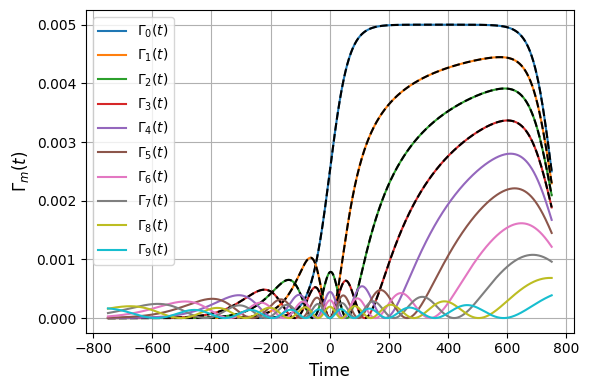

In [5]:
from scipy.integrate import cumulative_trapezoid 
from scipy.integrate import quad

m = 0
t0 = 0
t1 = 1500
N = 1500
t = np.linspace(t0, t1, N)
center = (t0+t1)/2
kappa =  2.5e-3*2*np.pi*2

plt.figure(figsize=(6, 4))
for m in range(10):
    ## cumulative_trapezoid
    xi_vals = np.array([xi_m(ti, m, kappa) for ti in t-center])
    abs_sq = np.abs(xi_vals)**2
    
    integral = cumulative_trapezoid(abs_sq, t-center, initial=0)
    denominator = 1 - integral
    denominator[denominator <= 1e-12] = np.nan
    Gamma_num = abs_sq / denominator / (2 * np.pi)
    plt.plot(t-center, Gamma_num, linestyle='-', label=fr"$\Gamma_{{{m}}}(t)$")

    ## quad
    # Gamma_list = []
    # for ti in t:
    #     integral, _ = quad(lambda tau: np.abs(xi_m(tau, m, kappa))**2, t0, ti)
    #     denominator = 1 - integral
    #     if denominator <= 1e-12:
    #         Gamma_list.append(np.nan)
    #     else:
    #         abs_sq = np.abs(xi_m(ti, m, kappa))**2
    #         Gamma_list.append(abs_sq / denominator / (2 * np.pi))
    # Gamma_num = np.array(Gamma_list)

    # plt.plot(t, Gamma_num, linestyle='-', label=fr"$\Gamma_{{{m}}}(t)$")
    if m <= 3:
        Gamma_ana = gamma_t(t, kappa / 2, form=m)
        plt.plot(t-center, Gamma_ana, linestyle='--', color="black")

plt.xlabel("Time", fontsize=12)
plt.ylabel(r"$\Gamma_m(t)$", fontsize=12)
plt.grid(True)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

mode 0 completed, energy: 0.999999999174478
mode 1 completed, energy: 0.999999967266825
mode 2 completed, energy: 0.999999381782792
mode 3 completed, energy: 0.999992609941303
mode 4 completed, energy: 0.999937344584247
mode 5 completed, energy: 0.999599940496866
mode 6 completed, energy: 0.9980067650284
mode 7 completed, energy: 0.992079328027207
mode 8 completed, energy: 0.974563797541094
mode 9 completed, energy: 0.933526454120205


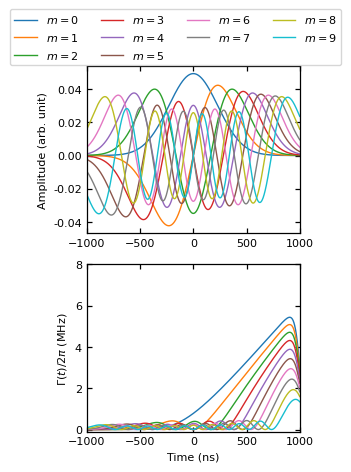

In [13]:
from matplotlib.ticker import FormatStrFormatter
duration = 2000
t0 = -duration/2
t1 =  duration/2
N = 2000
t = np.linspace(t0, t1, N)
center = (t0+t1)/2
t_vals = np.linspace(t0, t1, N)
kappa = 1.5e-6*2*np.pi*2

fig, axes = plt.subplots(2, 1, figsize=(3, 4.2))
for m in range(10):
    y_vals = hermite(t_vals, m, kappa)
    axes[0].plot(t_vals, y_vals, label=f'$m={m}$')

    abs_sq = np.abs(y_vals)**2
    
    integral = cumulative_trapezoid(abs_sq, t-center, initial=0)
    denominator = 1 - integral
    # denominator[denominator <= 1e-12] = np.nan
    Gamma_num = abs_sq / denominator / (2 * np.pi)
    axes[1].plot(t-center, Gamma_num*1000, linestyle='-')

    # ## quad
    # Gamma_list = []
    # for ti in t:
    #     integral, _ = quad(lambda tau: np.abs(xi_m(tau, m, kappa))**2, t0, ti)
    #     denominator = 1 - integral
    #     if denominator <= 1e-14:
    #         Gamma_list.append(np.nan)
    #     else:
    #         abs_sq = np.abs(xi_m(ti, m, kappa))**2
    #         Gamma_list.append(abs_sq / denominator / (2 * np.pi))
    # Gamma_num = np.array(Gamma_list)
    # axes[1].plot(t, Gamma_num, linestyle='-', label=fr"$\Gamma_{{{m}}}(t)$")

    # axes[0].set_ylim(-0.1, 0.12)
    axes[0].set_xlim(t0, t1)
    axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[0].set_ylabel('Amplitude (arb. unit)')
    axes[1].set_ylim(-0.1, 8)
    axes[1].set_xlim(t0, t1)
    axes[1].set_ylabel(r'$\Gamma(t)/2\pi$ (MHz)')
    print(f"mode {m} completed, energy:", integral[-1])

plt.xlabel('Time (ns)')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4)
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

# plt.savefig("Figapp2.pdf", bbox_inches='tight')
plt.show()

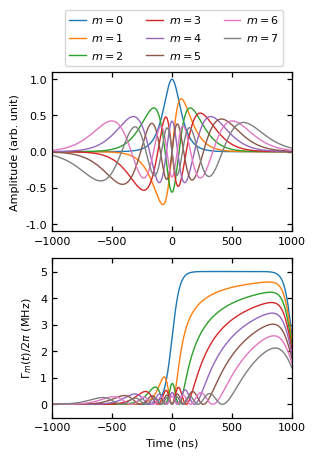

In [8]:
from matplotlib.ticker import FormatStrFormatter
duration = 2000
t_vals = np.linspace(-duration/2, duration/2, duration)

m = 0
t0 = -1000
t1 = 1000
N = 2000
t = np.linspace(t0, t1, N)
center = 0

fig, axes = plt.subplots(2, 1, figsize=(3.2, 4))
ax_scale = None
for m in range(8):
    y_vals = [xi_m(t, m, kappa) for t in t_vals]
    if m == 0:
        ax_scale = np.max(np.abs(y_vals))
    axes[0].plot(t_vals, np.array(y_vals)/ax_scale, label=f'$m={m}$')

    xi_vals = np.array([xi_m(ti, m, kappa) for ti in t-center])
    abs_sq = np.abs(xi_vals)**2
    
    integral = cumulative_trapezoid(abs_sq, t-center, initial=0)
    denominator = 1 - integral
    # denominator[denominator <= 1e-12] = np.nan
    Gamma_num = abs_sq / denominator / (2 * np.pi)
    axes[1].plot(t-center, Gamma_num*1000, linestyle='-')

    # ## quad
    # Gamma_list = []
    # for ti in t:
    #     integral, _ = quad(lambda tau: np.abs(xi_m(tau, m, kappa))**2, t0, ti)
    #     denominator = 1 - integral
    #     if denominator <= 1e-14:
    #         Gamma_list.append(np.nan)
    #     else:
    #         abs_sq = np.abs(xi_m(ti, m, kappa))**2
    #         Gamma_list.append(abs_sq / denominator / (2 * np.pi))
    # Gamma_num = np.array(Gamma_list)
    # axes[1].plot(t, Gamma_num, linestyle='-', label=fr"$\Gamma_{{{m}}}(t)$")

    axes[0].set_ylim(-1.1, 1.1)
    axes[0].set_xlim(-1000, 1000)
    axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[0].set_ylabel('Amplitude (arb. unit)')
    axes[1].set_ylim(-0.5, 5.5)
    axes[1].set_xlim(-1000, 1000)
    axes[1].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    axes[1].set_ylabel(r'$\Gamma_m(t)/2\pi$ (MHz)', x=-0.2)
    axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # 1桁
    axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.0f')) 

plt.xlabel('Time (ns)')

fig.legend(loc='upper center', bbox_to_anchor=(0.55, 1.14), ncol=3,
           handlelength=1.5,
    handletextpad=0.5,)
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

plt.savefig("Figapp21.pdf", bbox_inches='tight')
plt.show()

mode 0 completed, energy: 0.999999999999998
mode 1 completed, energy: 0.999999999999999
mode 2 completed, energy: 0.999999999999996
mode 3 completed, energy: 0.999999999999998
mode 4 completed, energy: 0.999999999999999
mode 5 completed, energy: 0.999999999999998
mode 6 completed, energy: 0.99999999999997
mode 7 completed, energy: 0.999999999999188
mode 8 completed, energy: 0.999999999979997
mode 9 completed, energy: 0.999999999621165
mode 10 completed, energy: 0.9999999943027
mode 11 completed, energy: 0.999999930853345
mode 12 completed, energy: 0.999999313884907
mode 13 completed, energy: 0.99999437844736
mode 14 completed, energy: 0.99996168437905
mode 15 completed, energy: 0.999781611808356
mode 16 completed, energy: 0.998955727132975
mode 17 completed, energy: 0.995805501647683
mode 18 completed, energy: 0.985857757885734
mode 19 completed, energy: 0.960085861113252


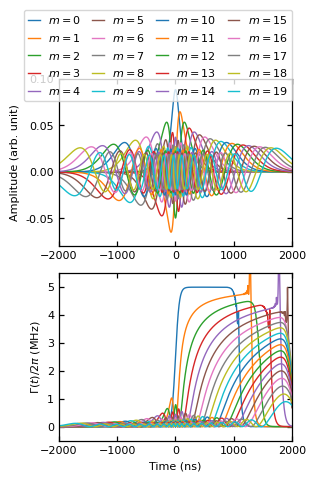

In [27]:
duration = 4000
t_vals = np.linspace(-duration/2, duration/2, duration)
kappa = 2.5e-3*2*np.pi*2
m = 0

center = 0

fig, axes = plt.subplots(2, 1, figsize=(3.2, 4.2))

for m in range(20):
    t0 = -duration/2
    t1 = duration/2
    N = duration
    t = np.linspace(t0, t1, N)

    y_vals = [xi_m(t, m, kappa) for t in t_vals]
    axes[0].plot(t_vals, y_vals, label=f'$m={m}$')

    t = np.linspace(t0, t1, N)
    xi_vals = np.array([xi_m(ti, m, kappa) for ti in t-center])
    abs_sq = np.abs(xi_vals)**2
    
    integral = cumulative_trapezoid(abs_sq, t-center, initial=0)
    denominator = 1 - integral
    # denominator[denominator <= 1e-12] = np.nan
    Gamma_num = abs_sq / denominator / (2 * np.pi)
    axes[1].plot(t-center, Gamma_num*1000, linestyle='-')

    # ## quad
    # Gamma_list = []
    # for ti in t:
    #     integral, _ = quad(lambda tau: np.abs(xi_m(tau, m, kappa))**2, t0, ti)
    #     denominator = 1 - integral
    #     if denominator <= 1e-14:
    #         Gamma_list.append(np.nan)
    #     else:
    #         abs_sq = np.abs(xi_m(ti, m, kappa))**2
    #         Gamma_list.append(abs_sq / denominator / (2 * np.pi))
    # Gamma_num = np.array(Gamma_list)
    # axes[1].plot(t, Gamma_num*1000, linestyle='-')

    axes[0].set_ylim(-0.08, 0.1)
    axes[0].set_xlim(t0, t1)
    axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[0].set_ylabel('Amplitude (arb. unit)')
    axes[1].set_ylim(-0.5, 5.5)
    axes[1].set_xlim(t0, t1)
    axes[1].set_ylabel(r'$\Gamma(t)/2\pi$ (MHz)')
    print(f"mode {m} completed, energy:", integral[-1])

plt.xlabel('Time (ns)')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.14), ncol=4,
           handlelength=1.0, 
            columnspacing=1 )
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

# plt.savefig("Figapp2_25.pdf", bbox_inches='tight')
plt.show()

In [30]:
def fourier_tr_padding_centered(x, y, center_x, n_padding=100):
    N = len(y)
    
    center_idx = np.argmin(np.abs(x - center_x))
    
    half_len = min(center_idx, N - center_idx - 1)
    y_centered = y[center_idx - half_len : center_idx + half_len + 1]
    
    pad_len = len(y_centered) * (n_padding - 1)
    pad_left = pad_len // 2
    pad_right = pad_len - pad_left
    y_pad = np.concatenate([np.zeros(pad_left, dtype=complex),
                            y_centered,
                            np.zeros(pad_right, dtype=complex)])
    y_pad_shifted = np.fft.ifftshift(y_pad)
    data_fft = np.fft.fft(y_pad_shifted)
    freq_fft = np.fft.fftfreq(len(y_pad), x[1] - x[0])
    
    data_fft = np.fft.fftshift(data_fft)
    freq_fft = np.fft.fftshift(freq_fft)
    
    return freq_fft, data_fft


mode 0 completed, energy: 0.9905155630133555
mode 1 completed, energy: 0.9727881232860909
mode 2 completed, energy: 0.9557745450434934
mode 3 completed, energy: 0.9399152466318728


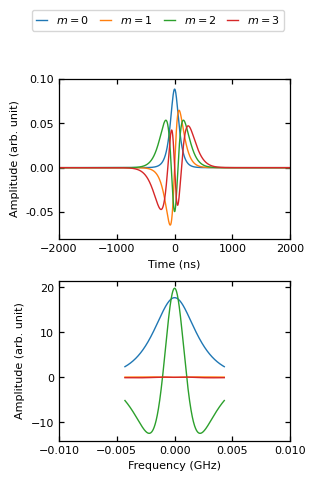

In [57]:
duration = 4000
t_vals = np.linspace(-duration/2, duration/2, duration)
kappa = 2.5e-3*2*np.pi*2
m = 0

center = 0

fig, axes = plt.subplots(2, 1, figsize=(3.2, 4.2))

for m in range(4):
    t0 = -duration/2
    t1 = duration/2
    N = duration
    t = np.linspace(t0, t1, N)

    y_vals = [xi_m(t, m, kappa) for t in t_vals]
    axes[0].plot(t_vals, y_vals, label=f'$m={m}$')

    xi_vals = np.array([xi_m(ti, m, kappa) for ti in t-center])
    half_bandwidth = 0.0043
    mask = (xfft >= -half_bandwidth) & (xfft <= half_bandwidth)
    xfft, fourier = fourier_tr_padding_centered(t, xi_vals, center)
    axes[1].plot(xfft[mask], fourier[mask].real)
    abs_sq = np.abs(fourier)**2
    integral = cumulative_trapezoid(abs_sq[mask], xfft[mask], initial=0)

    axes[0].set_ylim(-0.08, 0.1)
    axes[0].set_xlim(t0, t1)
    axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[0].set_ylabel('Amplitude (arb. unit)')
    axes[0].set_xlabel('Time (ns)')
    # axes[1].set_ylim(-0.5, 5.5)
    axes[1].set_xlim(-0.01, 0.01)
    axes[1].set_ylabel('Amplitude (arb. unit)')
    axes[1].set_xlabel('Frequency (GHz)')

    print(f"mode {m} completed, energy:", integral[-1])


fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.14), ncol=4,
           handlelength=1.0, 
            columnspacing=1 )
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

# plt.savefig("Figapp2_25.pdf", bbox_inches='tight')
plt.show()

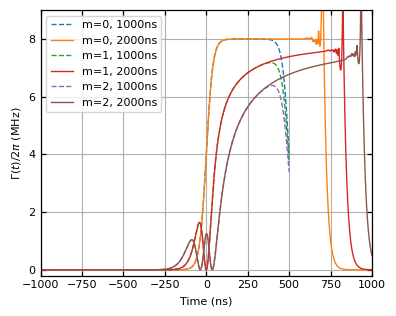

In [25]:
durations = [1000, 2000]
linestyles = ['--', '-']  # dashed: 1000, solid: 2000
labels = ['1000ns', '2000ns']



fig, ax = plt.subplots(figsize=(4, 3.2))

for m in [0, 1, 2]:
    for duration, style, label in zip(durations, linestyles, labels):
        t0, t1 = -duration/2, duration/2
        t = np.linspace(t0, t1, 1000)
        # t_vals を t_common に制限
        xi_vals = np.array([xi_m(ti, m, kappa) for ti in t-center])
        abs_sq = np.abs(xi_vals)**2
        
        integral = cumulative_trapezoid(abs_sq, t-center, initial=0)
        denominator = 1 - integral
        # denominator[denominator <= 1e-12] = np.nan
        Gamma_num = abs_sq / denominator / (2 * np.pi)
        ax.plot(t-center, Gamma_num*1000, linestyle=style, label=f'm={m}, {label}')

ax.set_xlim(t0, t1)
ax.set_ylim(-0.2, 9)
ax.set_xlabel('Time (ns)')
ax.set_ylabel(r'$\Gamma(t)/2\pi$ (MHz)')
ax.legend(fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()

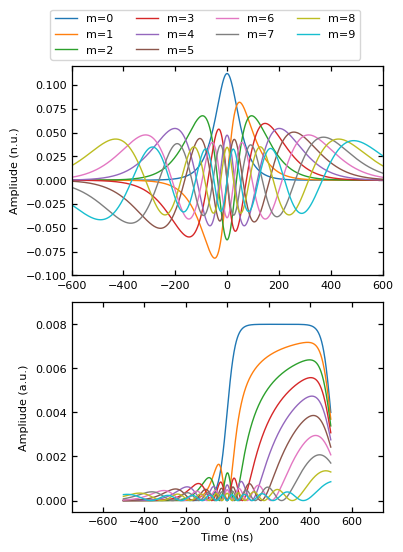

In [ ]:
duration = 2000
t_vals = np.linspace(-duration/2, duration/2, duration)

m = 0
t0 = -500
t1 = 500
N = 1000
t = np.linspace(t0, t1, N)
center = 0

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

for m in range(10):
    y_vals = [xi_m(t, m, kappa) for t in t_vals]
    axes[0].plot(t_vals, y_vals, label=f'm={m}')

    xi_vals = np.array([xi_m(ti, m, kappa) for ti in t-center])
    abs_sq = np.abs(xi_vals)**2
    
    integral = cumulative_trapezoid(abs_sq, t-center, initial=0)
    denominator = 1 - integral
    # denominator[denominator <= 1e-12] = np.nan
    Gamma_num = abs_sq / denominator / (2 * np.pi)
    axes[1].plot(t-center, Gamma_num, linestyle='-')

    axes[0].set_ylim(-0.1, 0.12)
    axes[0].set_xlim(-600, 600)
    axes[0].set_ylabel('Amplitude (arb. unit)')
    axes[1].set_ylim(-0.0005, 0.009)
    axes[1].set_xlim(-750, 750)
    axes[1].set_ylabel('Ampliude (a.u.)')

plt.xlabel('Time (ns)')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=4)
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

# plt.savefig("Figapp2_a.pdf")
plt.show()

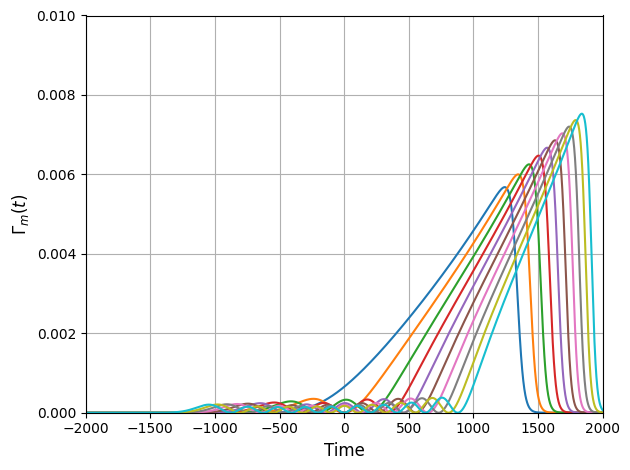

In [5]:
from scipy.signal import windows

duration = 6000
num_modes=10
NW = duration*kappa/8
dpss_modes = windows.dpss(duration, NW, Kmax=num_modes)
t_vals = np.linspace(-duration/2, duration/2, duration)

for m in range(10):
    ## cumulative_trapezoid
    dpss_vals = np.array(dpss_modes[m])
    abs_sq = np.abs(dpss_vals)**2
    norm = np.sqrt(np.sum(abs_sq) * (t_vals[1] - t_vals[0]))
    dpss_vals /= norm
    abs_sq = np.abs(dpss_vals)**2 

    epsilon = 1e-12
    cutoff_integral = 0.999
    integral = cumulative_trapezoid(abs_sq, t_vals, initial=0)
    safe_indices = np.where(integral <= cutoff_integral)[0]
    denominator = 1 - integral + epsilon  
    # denominator[denominator <= 1e-12] = np.nan
    Gamma_num = abs_sq / denominator / (2 * np.pi)
    plt.plot(t_vals, Gamma_num, linestyle='-', label=fr"$\Gamma_{{{m}}}(t)$")

    

plt.xlabel("Time", fontsize=12)
plt.ylabel(r"$\Gamma_m(t)$", fontsize=12)
plt.grid(True)
plt.xlim(-2000, 2000)
plt.ylim(0, 0.01)
# plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

using Analysis.py

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datataking import search_datadict_miyamura
from Analysis import WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit
import time as T

cd = "CDK174"
data_path = f"D:\\K_Sunada\\result\\{cd}"

readout_lo_freq = 9.47

name_dict = dict(
    data1 = dict(amp=0.2, date="2025-02-20", acquire_time="115134", params=dict(fit_start=250, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data2 = dict(amp=0.3, date="2025-02-20", acquire_time="121305", params=dict(fit_start=150, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)),
    data25 = dict(amp=0.35, date="2025-02-20", acquire_time="122035", params=dict(fit_start=150, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data3 = dict(amp=0.4, date="2025-02-20", acquire_time="123118", params=dict(fit_start=150, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data35 = dict(amp=0.425, date="2025-02-20", acquire_time="124210", params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
)
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

0.2 2025-02-20 115134
0.3 2025-02-20 121305
0.35 2025-02-20 122035
0.4 2025-02-20 123118
0.425 2025-02-20 124210


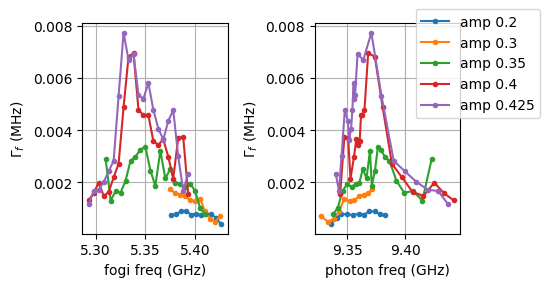

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


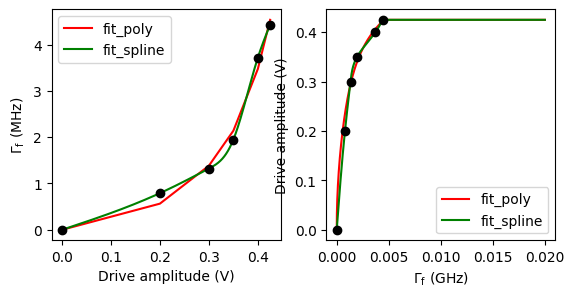

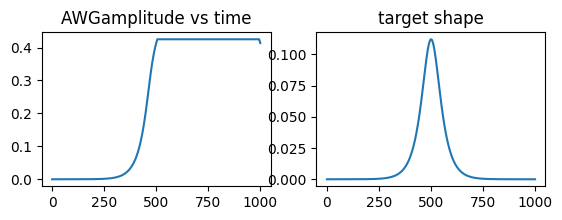

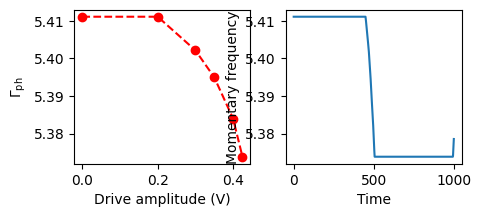

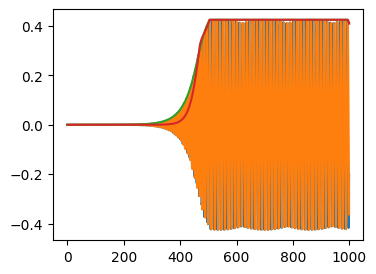

In [2]:
const = 4e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.29, target_freq, duration, const=const, form="nc", nc_id = 0)[0]

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


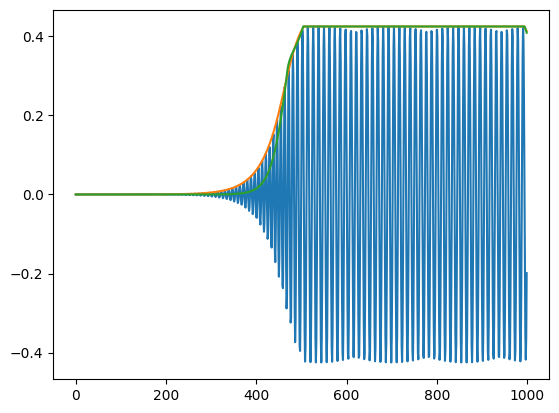

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


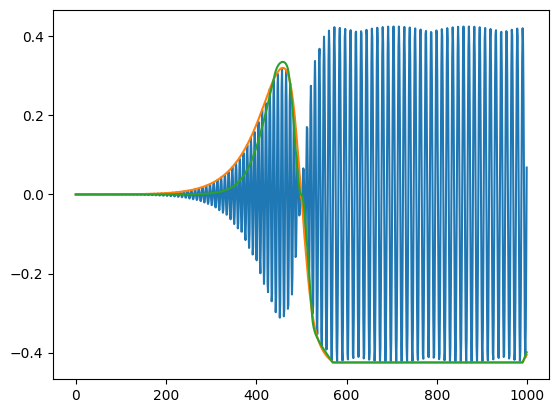

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


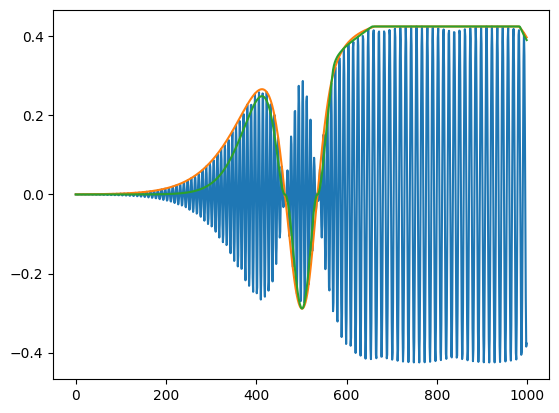

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


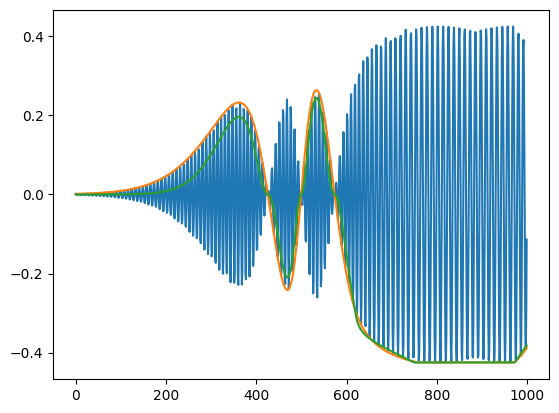

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


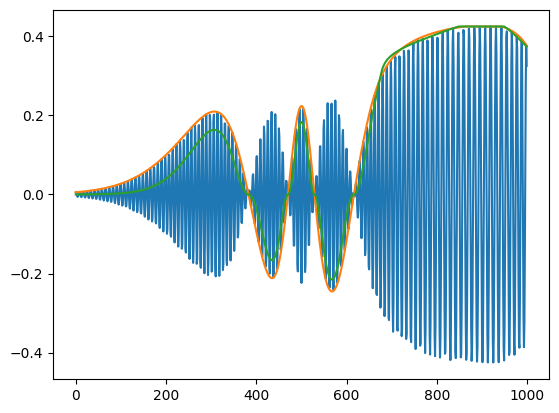

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


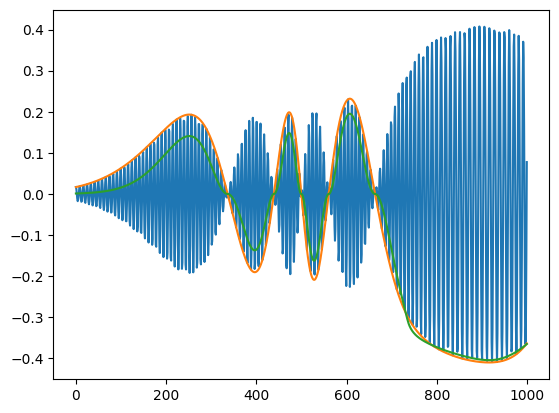

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


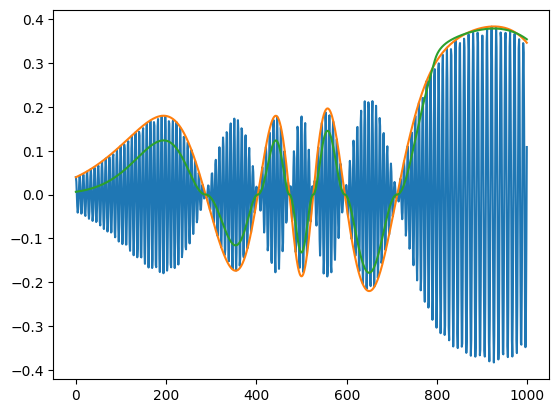

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


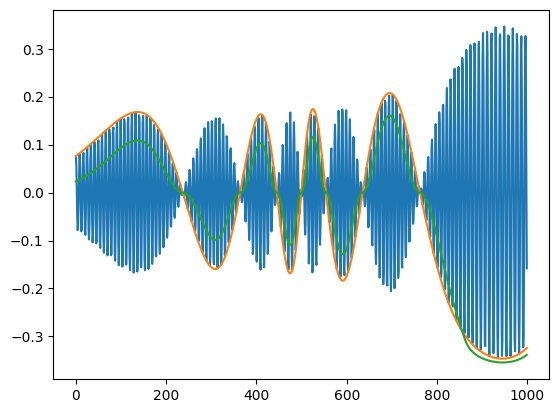

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


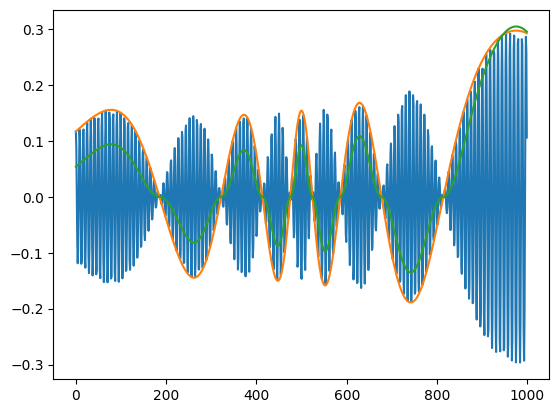

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}


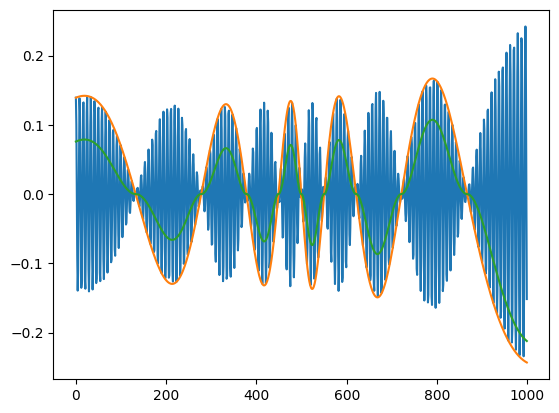

In [3]:
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T
ids = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 

for id in ids:
    for target_freq in [9.35]:
        control_pulse, control_envelope, control_pulse_sp, control_envelope_sp = dataobj.generate_control_pulse(
            5.29, target_freq, duration, const=const, form="nc", plot=False, nc_id=id
        )

        plt.plot(control_pulse)
        plt.plot(control_envelope)
        plt.plot(control_envelope_sp)
        plt.show()

1. photon emission with flipped fogi pulses
2. conpensate phase and amplitude distortion